In [2]:
import pandas as pd
data=pd.read_csv('../House_Rent_Dataset.csv')


In [3]:
y=data['Rent']
x=data.drop(['Rent','Posted On','Floor','Area Locality'],axis=1)
import category_encoders as ce
encoder=ce.LeaveOneOutEncoder()
X= encoder.fit_transform(x,y)
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x=scaler.fit_transform(X)

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
print(x_train)



[[0.2        0.16145181 0.99766603 ... 0.01433764 0.11111111 0.99718717]
 [0.2        0.077597   0.27314421 ... 0.0179296  0.11111111 0.00320846]
 [0.         0.0738423  0.27321031 ... 0.01804279 0.         0.00324939]
 ...
 [0.2        0.09887359 0.99982364 ... 0.99834514 0.11111111 0.99982779]
 [0.4        0.43679599 0.99921388 ... 0.01682786 0.22222222 0.99908152]
 [0.         0.05506884 0.99977673 ... 0.5868217  0.11111111 0.99977038]]


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
model.add(Dense(32, input_shape= (8,),activation ='relu'))
model.add(Dense(16,activation='relu'))

model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])
model.fit(x_train,y_train ,epochs=100,batch_size=32,validation_data=(x_test, y_test))

Epoch 1/100


c:\Users\hp\OneDrive\Desktop\AI Internship\srmccem\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 8092209664.0000 - val_accuracy: 0.0000e+00 - val_loss: 5019850240.0000
Epoch 2/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 8091875328.0000 - val_accuracy: 0.0000e+00 - val_loss: 5019274240.0000
Epoch 3/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 8091051008.0000 - val_accuracy: 0.0000e+00 - val_loss: 5018190336.0000
Epoch 4/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 8089722880.0000 - val_accuracy: 0.0000e+00 - val_loss: 5016632320.0000
Epoch 5/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 8087933440.0000 - val_accuracy: 0.0000e+00 - val_loss: 5014595072.0000
Epoch 6/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 8085726208.0000 - val_accuracy: 0.0000e+00 - val_loss: 5012220928.0000
Epoch 7/100
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss

In [5]:
import numpy as np
pred=model.predict(x_test)
pred=np.argmax(pred, axis=1) 
pred=pred+3
print(pred)

model.save('House_Price_Model.h5')
print("Model Save Successfully")

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


[13 13 13 ... 13 13 13]
Model Save Successfully


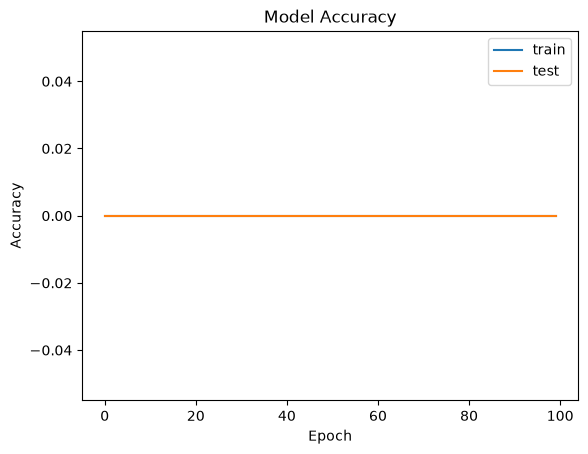

In [10]:
import matplotlib.pyplot as plt
plt.plot(model.history.history['accuracy'], label='train')
plt.plot(model.history.history['val_accuracy'], label='test')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()